# 5. Correlation is not causation

**The mistake in one sentence:** two things rise together, so we decide one causes the other.

Running on Google Colab? Run the next cell first. It downloads the repo so the data files are there. On your own computer you can skip it.

In [1]:
import os
from pathlib import Path
if not any((p / "src").exists() for p in [Path.cwd(), *Path.cwd().parents]):
    !git clone https://github.com/CS42org/data-make-sins.git
    os.chdir("data-make-sins/notebooks")

In [2]:
import sys
from pathlib import Path
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.append(str(root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import dms

dms.style()

## The real case

On 10 October 2012 the New England Journal of Medicine published a short paper: countries that eat more chocolate win more Nobel prizes. 23 countries, correlation 0.79. Reuters ran it under the headline "Eat chocolate, win the Nobel Prize?"

The values below are read from the published figure, so they are approximate. GDP per person is added as a possible hidden factor.

In [3]:
df = pd.read_csv(dms.DATA / "chocolate_nobel.csv")
df.head()

,country,chocolate_kg_per_person,nobel_per_10m,gdp_per_capita_usd
0,Switzerland,11.9,31.9,83000
1,Sweden,6.4,31.9,57000
2,Denmark,8.5,25.3,58000
3,Austria,8.8,24.3,48000
4,Norway,9.2,23.4,100000


In [4]:
df[["chocolate_kg_per_person", "nobel_per_10m", "gdp_per_capita_usd"]].corr().round(2)

,chocolate_kg_per_person,nobel_per_10m,gdp_per_capita_usd
chocolate_kg_per_person,1.00,0.79,0.65
nobel_per_10m,0.79,1.00,0.71
gdp_per_capita_usd,0.65,0.71,1.00


In [5]:
r = df.chocolate_kg_per_person.corr(df.nobel_per_10m)
slope, intercept = np.polyfit(df.chocolate_kg_per_person, df.nobel_per_10m, 1)

fig, ax = plt.subplots()
ax.scatter(df.chocolate_kg_per_person, df.nobel_per_10m, s=50, color=dms.BLUE)
xs = np.linspace(0, 12.5, 2)
ax.plot(xs, slope * xs + intercept, color=dms.RED, lw=2)
for _, row in df[df.country.isin(["Switzerland", "Sweden", "Germany", "United States", "China", "Japan"])].iterrows():
    ax.annotate(row.country, (row.chocolate_kg_per_person, row.nobel_per_10m), (5, 4), textcoords="offset points", fontsize=9)
ax.set_xlabel("chocolate, kg per person per year"); ax.set_ylabel("Nobel prizes per 10 million people")
ax.set_title(f"A strong line, r = {r:.2f}. Does chocolate make Nobel winners?")
dms.save(fig, "05_chocolate_nobel.png")
plt.show()

## What a hidden third factor does

A simulation makes the mechanism clear. Wealth pushes chocolate up. Wealth pushes prizes up. Chocolate and prizes never touch each other, yet they are strongly correlated. Remove the effect of wealth from both and the correlation disappears.

In [6]:
rng = np.random.default_rng(1)
n = 2000
wealth = rng.normal(size=n)
sim = pd.DataFrame({
    "wealth": wealth,
    "chocolate": wealth + rng.normal(scale=0.7, size=n),
    "prizes": wealth + rng.normal(scale=0.7, size=n),
})

def remove_effect_of(x, control):
    slope, intercept = np.polyfit(control, x, 1)
    return x - (slope * control + intercept)

sim["chocolate_without_wealth"] = remove_effect_of(sim.chocolate, sim.wealth)
sim["prizes_without_wealth"] = remove_effect_of(sim.prizes, sim.wealth)

print("chocolate vs prizes             r =", round(sim.chocolate.corr(sim.prizes), 2))
print("same, after removing wealth     r =", round(sim.chocolate_without_wealth.corr(sim.prizes_without_wealth), 2))

chocolate vs prizes             r = 0.68
same, after removing wealth     r = 0.02


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(sim.chocolate, sim.prizes, s=8, alpha=0.5, color=dms.BLUE)
axes[0].set_title(f"Raw data: r = {sim.chocolate.corr(sim.prizes):.2f}")
axes[1].scatter(sim.chocolate_without_wealth, sim.prizes_without_wealth, s=8, alpha=0.5, color=dms.GREY)
axes[1].set_title(f"After removing wealth: r = {sim.chocolate_without_wealth.corr(sim.prizes_without_wealth):.2f}")
for ax in axes:
    ax.set_xlabel("chocolate"); ax.set_ylabel("prizes")
dms.save(fig, "05_hidden_factor.png")
plt.show()

## Back to the real countries

Do the same with the approximate country data, using GDP per person as the control.

In [8]:
df["log_gdp"] = np.log(df.gdp_per_capita_usd)
choc_adj = remove_effect_of(df.chocolate_kg_per_person, df.log_gdp)
nobel_adj = remove_effect_of(df.nobel_per_10m, df.log_gdp)
print("chocolate vs Nobel              r =", round(r, 2))
print("same, after removing GDP        r =", round(np.corrcoef(choc_adj, nobel_adj)[0, 1], 2))

chocolate vs Nobel              r = 0.79
same, after removing GDP        r = 0.64


The link gets weaker but does not vanish. That is normal. Money is one hidden factor. Research spending, universities, language, history and climate are others, and the paper measured none of them. The lesson is not that wealth explains everything. The lesson is that a strong line is never proof of a cause.

## Animated figure

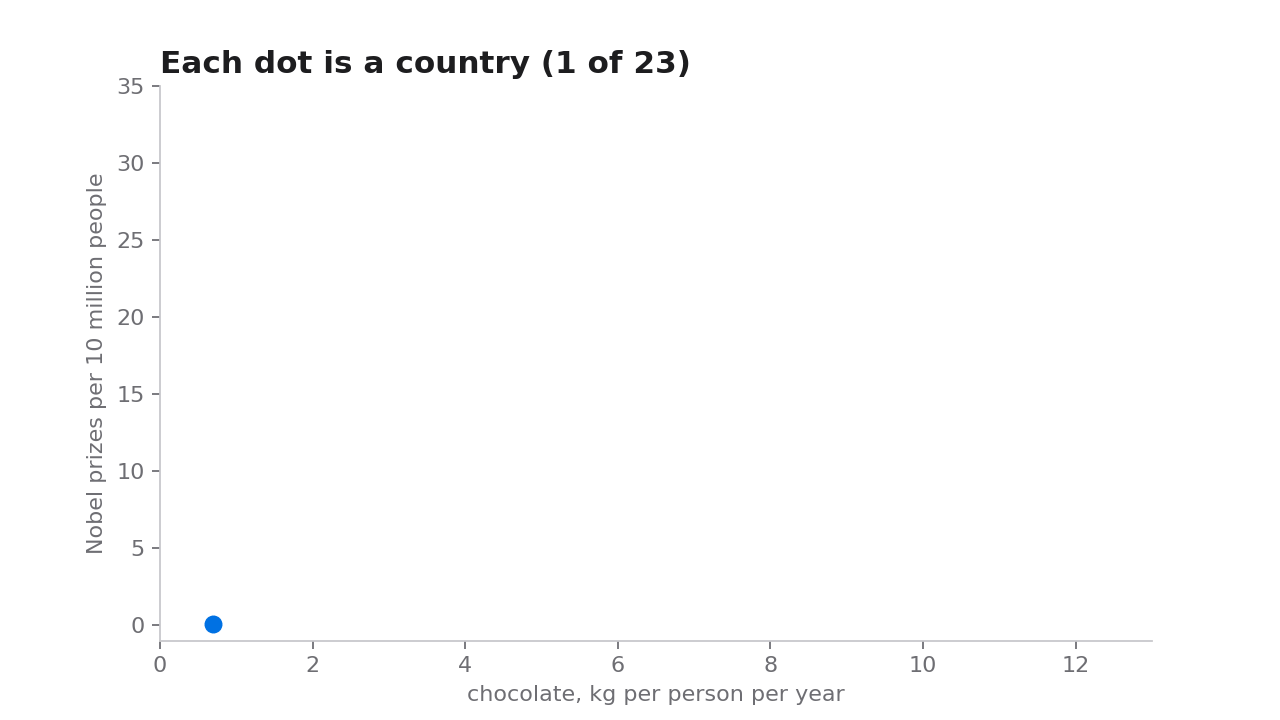

In [9]:
fig, ax = plt.subplots()
ax.set_xlim(0, 13); ax.set_ylim(-1, 35)
ax.set_xlabel("chocolate, kg per person per year"); ax.set_ylabel("Nobel prizes per 10 million people")
order = df.sort_values("chocolate_kg_per_person")
pts = ax.scatter([], [], s=50, color=dms.BLUE)
line, = ax.plot([], [], color=dms.RED, lw=2)
title = ax.set_title("")
sizes = 20 + 140 * (order.gdp_per_capita_usd - order.gdp_per_capita_usd.min()) / (order.gdp_per_capita_usd.max() - order.gdp_per_capita_usd.min())
n_pts, n_line, hold = len(order), 20, 12

def update(i):
    if i < n_pts:
        pts.set_offsets(order[["chocolate_kg_per_person", "nobel_per_10m"]].values[: i + 1])
        title.set_text(f"Each dot is a country ({i + 1} of {n_pts})")
    elif i < n_pts + n_line:
        k = (i - n_pts + 1) / n_line
        xs = np.linspace(0, 12.5 * k, 2)
        line.set_data(xs, slope * xs + intercept)
        title.set_text(f"Draw the trend: r = {r:.2f}")
    elif i < n_pts + n_line + hold:
        title.set_text("Now size each dot by how rich the country is")
    else:
        pts.set_sizes(sizes.values)
        title.set_text("Money buys chocolate and funds laboratories")
    return pts, line, title

anim = FuncAnimation(fig, update, frames=n_pts + n_line + hold + 15, interval=150)
gif = dms.FIG / "05_chocolate_nobel.gif"
anim.save(gif, writer=PillowWriter(fps=7))
plt.close(fig)
display(Image(filename=str(gif)))

## Better method

Look for a third thing that moves both. The best test is a trial where chance decides who gets the treatment, because chance does not care about wealth. If a trial is impossible, put the suspected third thing into the model and see how much of the link survives.

## Ask this

What third thing moves both?